In [3]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy import stats
from scipy.stats import skew
from scipy.special import boxcox1p

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("\n✓ All libraries imported successfully!")

print("\n" + "-"*70)
print("Loading data from data.csv...")
print("-"*70)

try:
    df_original = pd.read_csv('data.csv')
    print(f"\n✓ Data loaded successfully!")
    print(f"  Dataset Shape: {df_original.shape}")
    print(f"  Total Samples: {df_original.shape[0]}")
    print(f"  Total Features: {df_original.shape[1]}")
except FileNotFoundError:
    print("\n✗ ERROR: data.csv file not found!")
    print("  Please ensure data.csv is in the same directory as this notebook.")
    raise




✓ All libraries imported successfully!

----------------------------------------------------------------------
Loading data from data.csv...
----------------------------------------------------------------------

✓ Data loaded successfully!
  Dataset Shape: (1460, 81)
  Total Samples: 1460
  Total Features: 81



2.1 TARGET VARIABLE ANALYSIS (SalePrice)
----------------------------------------------------------------------

Sale Price Statistics:
  Mean:        $180,921.20
  Median:      $163,000.00
  Min:         $34,900.00
  Max:         $755,000.00
  Std Dev:     $79,442.50
  Skewness:    1.8829
  Kurtosis:    6.5363


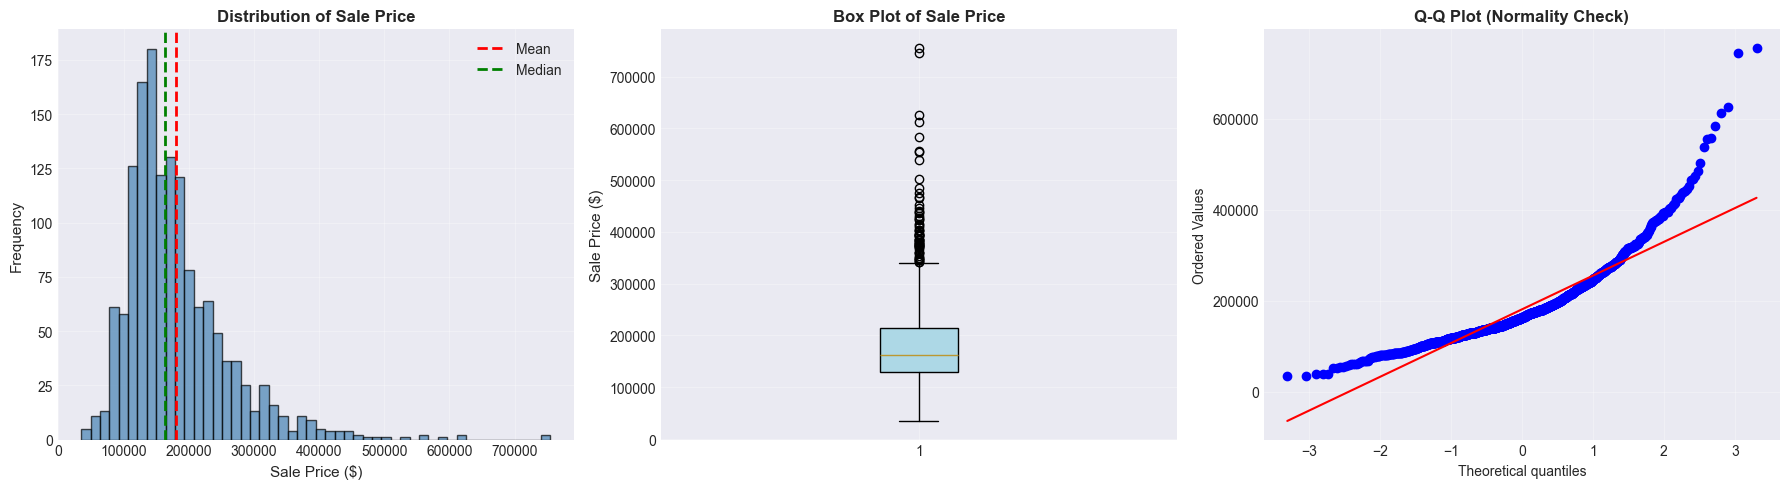


✓ Target variable visualization saved: 01_saleprice_distribution.png

Total features with missing values: 19
Total missing data points: 7829

Top 15 features with missing values:
              Missing_Count  Percentage
PoolQC                 1453   99.520548
MiscFeature            1406   96.301370
Alley                  1369   93.767123
Fence                  1179   80.753425
MasVnrType              872   59.726027
FireplaceQu             690   47.260274
LotFrontage             259   17.739726
GarageType               81    5.547945
GarageYrBlt              81    5.547945
GarageFinish             81    5.547945
GarageQual               81    5.547945
GarageCond               81    5.547945
BsmtFinType2             38    2.602740
BsmtExposure             38    2.602740
BsmtFinType1             37    2.534247


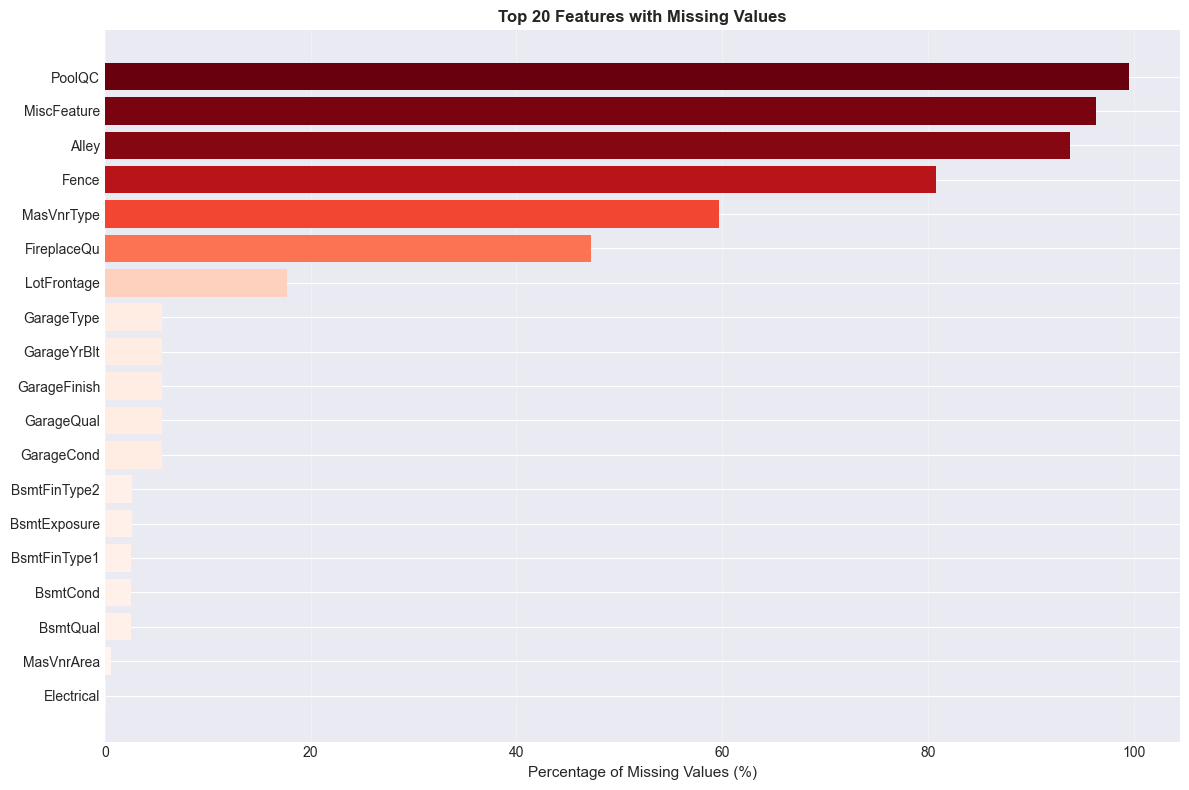


✓ Missing values visualization saved: 02_missing_values.png

Total numerical features: 36

Top 15 features positively correlated with SalePrice:
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
LotFrontage     0.351799

Top 5 features negatively correlated with SalePrice:
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907


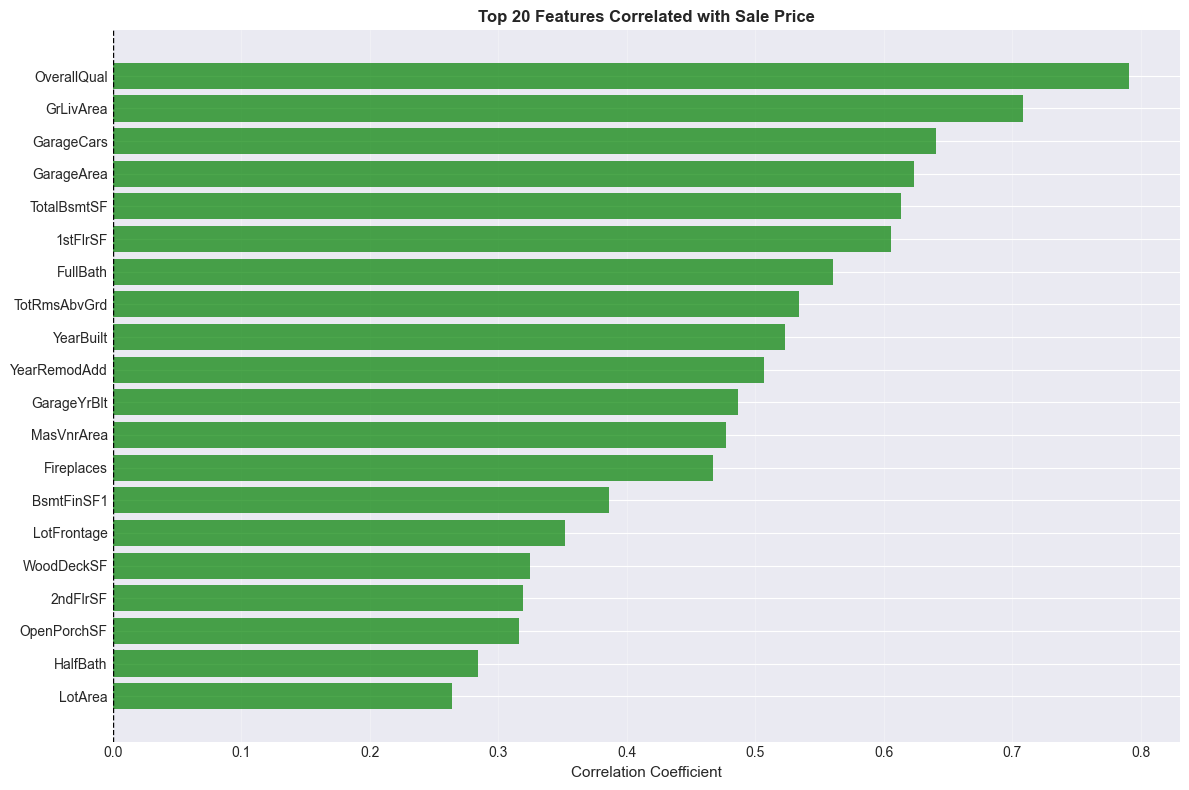


✓ Correlation visualization saved: 03_feature_correlations.png


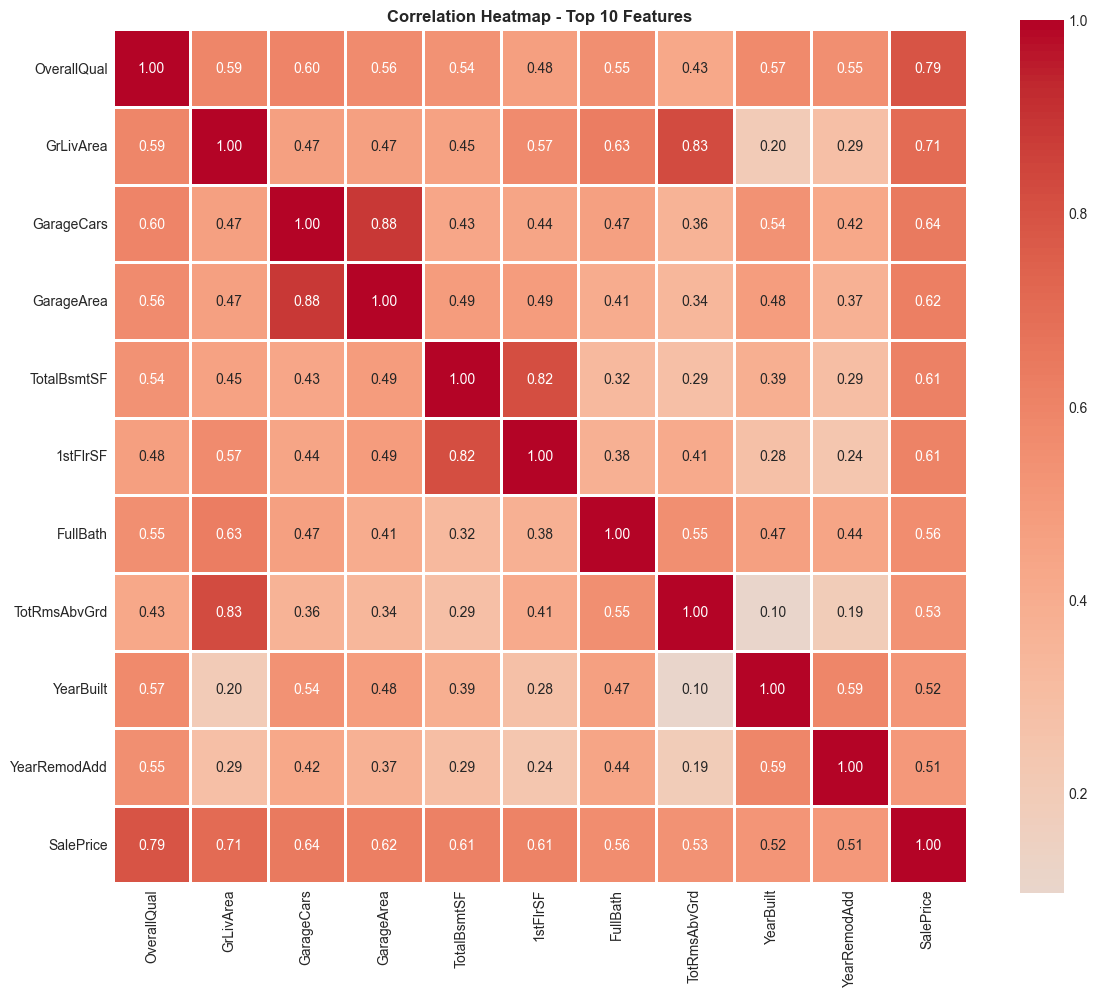

✓ Correlation heatmap saved: 04_correlation_heatmap.png


2.4 CATEGORICAL FEATURES ANALYSIS
----------------------------------------------------------------------

Total categorical features: 43


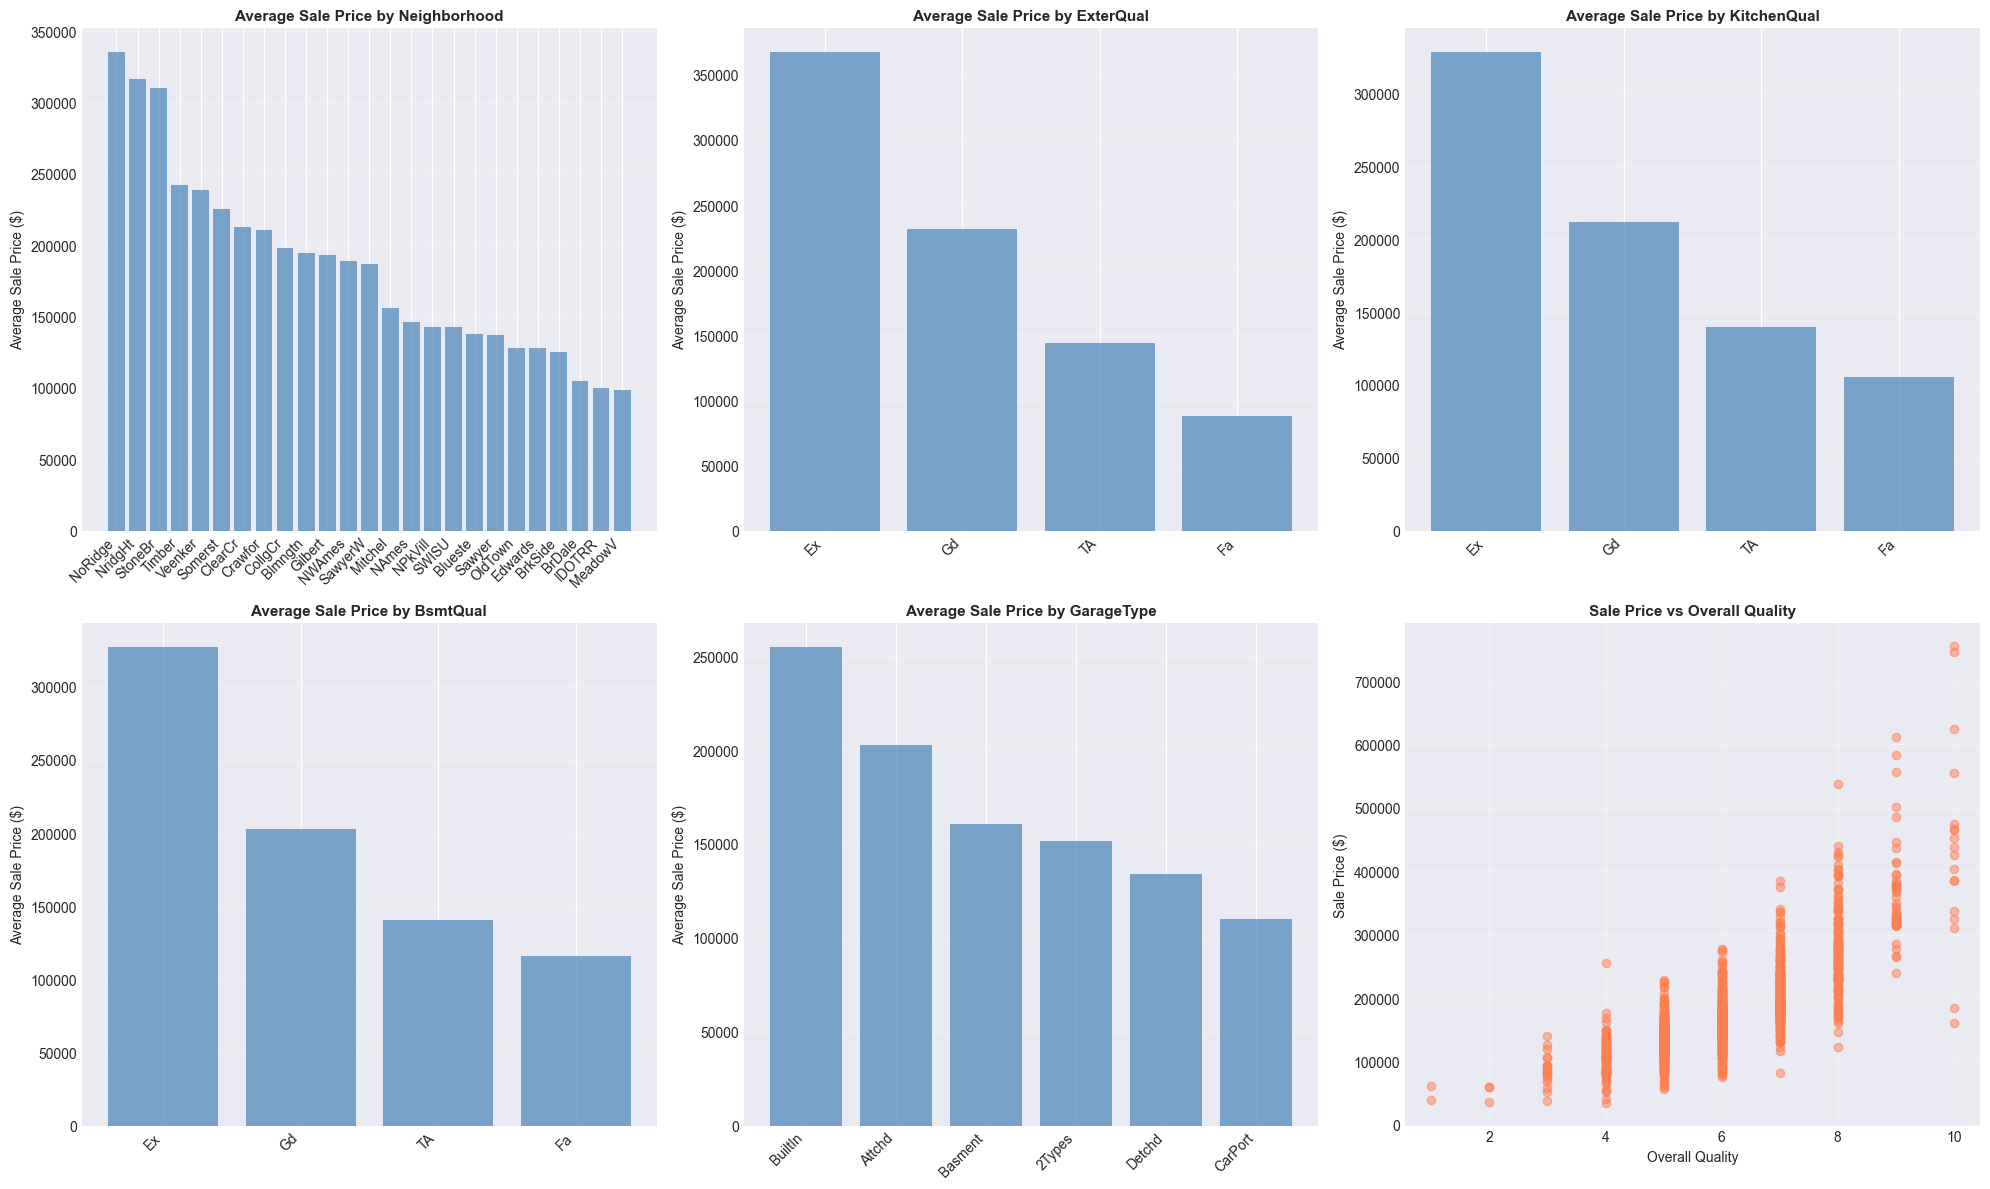


✓ Categorical analysis saved: 05_categorical_analysis.png


In [5]:

print("\n2.1 TARGET VARIABLE ANALYSIS (SalePrice)")
print("-"*70)

if 'SalePrice' not in df_original.columns:
    print("\n✗ ERROR: 'SalePrice' column not found in dataset!")
    print("  Available columns:", df_original.columns.tolist()[:10], "...")
    raise ValueError("Target variable 'SalePrice' not found")

print(f"\nSale Price Statistics:")
print(f"  Mean:        ${df_original['SalePrice'].mean():,.2f}")
print(f"  Median:      ${df_original['SalePrice'].median():,.2f}")
print(f"  Min:         ${df_original['SalePrice'].min():,.2f}")
print(f"  Max:         ${df_original['SalePrice'].max():,.2f}")
print(f"  Std Dev:     ${df_original['SalePrice'].std():,.2f}")
print(f"  Skewness:    {df_original['SalePrice'].skew():.4f}")
print(f"  Kurtosis:    {df_original['SalePrice'].kurtosis():.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(df_original['SalePrice'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Sale Price ($)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Distribution of Sale Price', fontsize=12, fontweight='bold')
axes[0].axvline(df_original['SalePrice'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0].axvline(df_original['SalePrice'].median(), color='green', linestyle='--', linewidth=2, label='Median')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Box plot
bp = axes[1].boxplot(df_original['SalePrice'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
axes[1].set_ylabel('Sale Price ($)', fontsize=11)
axes[1].set_title('Box Plot of Sale Price', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

# Q-Q plot
stats.probplot(df_original['SalePrice'], dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot (Normality Check)', fontsize=12, fontweight='bold')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('01_saleprice_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Target variable visualization saved: 01_saleprice_distribution.png")



missing = df_original.isnull().sum()
missing_percent = 100 * missing / len(df_original)
missing_table = pd.DataFrame({
    'Missing_Count': missing,
    'Percentage': missing_percent
})
missing_table = missing_table[missing_table['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

print(f"\nTotal features with missing values: {len(missing_table)}")
print(f"Total missing data points: {missing_table['Missing_Count'].sum()}")

if len(missing_table) > 0:
    print("\nTop 15 features with missing values:")
    print(missing_table.head(15).to_string())
    
    # Visualize missing values
    plt.figure(figsize=(12, 8))
    top_missing = missing_table.head(20)
    colors = plt.cm.Reds(top_missing['Percentage'] / 100)
    plt.barh(range(len(top_missing)), top_missing['Percentage'], color=colors)
    plt.yticks(range(len(top_missing)), top_missing.index)
    plt.xlabel('Percentage of Missing Values (%)', fontsize=11)
    plt.title('Top 20 Features with Missing Values', fontsize=12, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('02_missing_values.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("\n✓ Missing values visualization saved: 02_missing_values.png")
else:
    print("\n✓ No missing values found in dataset!")



numerical_features = df_original.select_dtypes(include=[np.number]).columns.tolist()
if 'Id' in numerical_features:
    numerical_features.remove('Id')
if 'SalePrice' in numerical_features:
    numerical_features.remove('SalePrice')

print(f"\nTotal numerical features: {len(numerical_features)}")

correlations = df_original[numerical_features + ['SalePrice']].corr()['SalePrice'].drop('SalePrice').sort_values(ascending=False)

print("\nTop 15 features positively correlated with SalePrice:")
print(correlations.head(15).to_string())

print("\nTop 5 features negatively correlated with SalePrice:")
print(correlations.tail(5).to_string())

plt.figure(figsize=(12, 8))
top_corr = correlations.head(20)
colors = ['green' if x > 0 else 'red' for x in top_corr.values]
plt.barh(range(len(top_corr)), top_corr.values, color=colors, alpha=0.7)
plt.yticks(range(len(top_corr)), top_corr.index)
plt.xlabel('Correlation Coefficient', fontsize=11)
plt.title('Top 20 Features Correlated with Sale Price', fontsize=12, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('03_feature_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Correlation visualization saved: 03_feature_correlations.png")

top_features = correlations.head(10).index.tolist() + ['SalePrice']
plt.figure(figsize=(12, 10))
sns.heatmap(df_original[top_features].corr(), annot=True, fmt='.2f', 
            cmap='coolwarm', center=0, square=True, linewidths=1)
plt.title('Correlation Heatmap - Top 10 Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('04_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Correlation heatmap saved: 04_correlation_heatmap.png")

print("\n\n2.4 CATEGORICAL FEATURES ANALYSIS")
print("-"*70)

categorical_features = df_original.select_dtypes(include=['object']).columns.tolist()
print(f"\nTotal categorical features: {len(categorical_features)}")

important_cat_features = ['Neighborhood', 'ExterQual', 'KitchenQual', 'BsmtQual', 'GarageType']
available_cat_features = [f for f in important_cat_features if f in df_original.columns]

if len(available_cat_features) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    axes = axes.ravel()
    
    for idx, feature in enumerate(available_cat_features):
        avg_price = df_original.groupby(feature)['SalePrice'].mean().sort_values(ascending=False)
        axes[idx].bar(range(len(avg_price)), avg_price.values, alpha=0.7, color='steelblue')
        axes[idx].set_xticks(range(len(avg_price)))
        axes[idx].set_xticklabels(avg_price.index, rotation=45, ha='right')
        axes[idx].set_ylabel('Average Sale Price ($)', fontsize=10)
        axes[idx].set_title(f'Average Sale Price by {feature}', fontsize=11, fontweight='bold')
        axes[idx].grid(axis='y', alpha=0.3)
    
    if 'OverallQual' in df_original.columns:
        axes[5].scatter(df_original['OverallQual'], df_original['SalePrice'], 
                       alpha=0.5, color='coral')
        axes[5].set_xlabel('Overall Quality', fontsize=10)
        axes[5].set_ylabel('Sale Price ($)', fontsize=10)
        axes[5].set_title('Sale Price vs Overall Quality', fontsize=11, fontweight='bold')
        axes[5].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('05_categorical_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✓ Categorical analysis saved: 05_categorical_analysis.png")



In [7]:


df = df_original.copy()

print("\n3.1 INITIAL DATA PREPARATION")
print("-"*70)

if 'Id' in df.columns:
    df = df.drop('Id', axis=1)
    print("✓ Removed 'Id' column")

print(f"Working dataset shape: {df.shape}")

print("\n3.2 SPLITTING FEATURES AND TARGET")
print("-"*70)

y = df['SalePrice'].copy()
X = df.drop('SalePrice', axis=1)

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

y_log = np.log1p(y)
print(f"\nOriginal SalePrice skewness: {y.skew():.4f}")
print(f"Log-transformed SalePrice skewness: {y_log.skew():.4f}")
print("✓ Applied log transformation to reduce skewness")

print("\n\n3.3 FEATURE ENGINEERING")
print("-"*70)

print("\nCreating new features...")

if all(col in X.columns for col in ['TotalBsmtSF', '1stFlrSF', '2ndFlrSF']):
    X['TotalSF'] = X['TotalBsmtSF'] + X['1stFlrSF'] + X['2ndFlrSF']
    print("  ✓ TotalSF (total square footage)")

if all(col in X.columns for col in ['FullBath', 'HalfBath', 'BsmtFullBath', 'BsmtHalfBath']):
    X['TotalBath'] = X['FullBath'] + 0.5*X['HalfBath'] + X['BsmtFullBath'] + 0.5*X['BsmtHalfBath']
    print("  ✓ TotalBath (total bathrooms)")

porch_cols = ['OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch']
if all(col in X.columns for col in porch_cols):
    X['TotalPorchSF'] = X[porch_cols].sum(axis=1)
    print("  ✓ TotalPorchSF (total porch area)")

if all(col in X.columns for col in ['YrSold', 'YearBuilt', 'YearRemodAdd']):
    X['HouseAge'] = X['YrSold'] - X['YearBuilt']
    X['RemodAge'] = X['YrSold'] - X['YearRemodAdd']
    print("  ✓ HouseAge, RemodAge")

if '2ndFlrSF' in X.columns:
    X['Has2ndFloor'] = (X['2ndFlrSF'] > 0).astype(int)
    print("  ✓ Has2ndFloor")

if 'GarageArea' in X.columns:
    X['HasGarage'] = (X['GarageArea'] > 0).astype(int)
    print("  ✓ HasGarage")

if 'TotalBsmtSF' in X.columns:
    X['HasBsmt'] = (X['TotalBsmtSF'] > 0).astype(int)
    print("  ✓ HasBsmt")

if 'Fireplaces' in X.columns:
    X['HasFireplace'] = (X['Fireplaces'] > 0).astype(int)
    print("  ✓ HasFireplace")

if 'PoolArea' in X.columns:
    X['HasPool'] = (X['PoolArea'] > 0).astype(int)
    print("  ✓ HasPool")

print(f"\n✓ Total features after engineering: {X.shape[1]}")

print("\n\n3.4 HANDLING MISSING VALUES")
print("-"*70)

print(f"Missing values before handling: {X.isnull().sum().sum()}")

none_features = ['Alley', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
                 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
                 'PoolQC', 'Fence', 'MiscFeature']

for feature in none_features:
    if feature in X.columns:
        X[feature] = X[feature].fillna('None')

zero_features = ['GarageYrBlt', 'GarageArea', 'GarageCars', 'BsmtFinSF1', 'BsmtFinSF2',
                 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea']

for feature in zero_features:
    if feature in X.columns:
        X[feature] = X[feature].fillna(0)

numerical_cols = X.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    if X[col].isnull().sum() > 0:
        X[col] = X[col].fillna(X[col].median())

categorical_cols = X.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if X[col].isnull().sum() > 0:
        X[col] = X[col].fillna(X[col].mode()[0])

print(f"Missing values after handling: {X.isnull().sum().sum()}")
print("✓ All missing values handled")

print("\n\n3.5 ENCODING CATEGORICAL VARIABLES")
print("-"*70)

quality_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
quality_features = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
                    'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']

for feature in quality_features:
    if feature in X.columns:
        X[feature] = X[feature].map(quality_map)

print(f"✓ Ordinal encoding applied to {len([f for f in quality_features if f in X.columns])} quality features")

X = pd.get_dummies(X, drop_first=True)

print(f"✓ One-hot encoding applied")
print(f"Total features after encoding: {X.shape[1]}")

print("\n\n3.6 HANDLING SKEWED FEATURES")
print("-"*70)

numeric_feats = X.select_dtypes(include=['int64', 'float64']).columns

skewed_feats = X[numeric_feats].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)
skewness = pd.DataFrame({'Skew': skewed_feats})
skewness = skewness[abs(skewness['Skew']) > 0.75]

print(f"Number of highly skewed features (|skew| > 0.75): {len(skewness)}")

if len(skewness) > 0:
    skewed_features = skewness.index
    lam = 0.15
    for feat in skewed_features:
        X[feat] = boxcox1p(X[feat], lam)
    print(f"✓ Box-Cox transformation applied to {len(skewed_features)} skewed features")





3.1 INITIAL DATA PREPARATION
----------------------------------------------------------------------
✓ Removed 'Id' column
Working dataset shape: (1460, 80)

3.2 SPLITTING FEATURES AND TARGET
----------------------------------------------------------------------
Features shape: (1460, 79)
Target shape: (1460,)

Original SalePrice skewness: 1.8829
Log-transformed SalePrice skewness: 0.1213
✓ Applied log transformation to reduce skewness


3.3 FEATURE ENGINEERING
----------------------------------------------------------------------

Creating new features...
  ✓ TotalSF (total square footage)
  ✓ TotalBath (total bathrooms)
  ✓ TotalPorchSF (total porch area)
  ✓ HouseAge, RemodAge
  ✓ Has2ndFloor
  ✓ HasGarage
  ✓ HasBsmt
  ✓ HasFireplace
  ✓ HasPool

✓ Total features after engineering: 89


3.4 HANDLING MISSING VALUES
----------------------------------------------------------------------
Missing values before handling: 7829
Missing values after handling: 0
✓ All missing values handled


In [8]:


print("\n4.1 SPLITTING DATA INTO TRAIN AND TEST SETS")
print("-"*70)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set size: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"Number of features: {X_train.shape[1]}")

def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    """Train and evaluate a model"""
    print(f"\n{name}")
    print("-" * 60)
    
    # Train
    model.fit(X_train, y_train)
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Metrics 
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    # Convert back to original scale
    train_mae = mean_absolute_error(np.expm1(y_train), np.expm1(y_train_pred))
    test_mae = mean_absolute_error(np.expm1(y_test), np.expm1(y_test_pred))
    
    print(f"Training RMSE (log):     {train_rmse:.4f}")
    print(f"Test RMSE (log):         {test_rmse:.4f}")
    print(f"Training R² Score:       {train_r2:.4f}")
    print(f"Test R² Score:           {test_r2:.4f}")
    print(f"Test MAE (original $):   ${test_mae:,.2f}")
    
    # Cross-validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, 
                                scoring='neg_mean_squared_error')
    cv_rmse = np.sqrt(-cv_scores.mean())
    cv_std = cv_scores.std()
    print(f"Cross-Val RMSE:          {cv_rmse:.4f} (+/- {cv_std:.4f})")
    
    return {
        'model': model,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'test_mae': test_mae,
        'cv_rmse': cv_rmse,
        'predictions': y_test_pred
    }

print("\n\n4.3 TRAINING MULTIPLE MODELS")
print("-"*70)

model_results = {}

# Model 1: Linear Regression
print("\n" + "="*70)
print("MODEL 1: LINEAR REGRESSION")
print("="*70)
model_results['Linear Regression'] = evaluate_model(
    "Linear Regression", 
    LinearRegression(), 
    X_train, y_train, X_test, y_test
)

# Model 2: Ridge Regression
print("\n" + "="*70)
print("MODEL 2: RIDGE REGRESSION (L2 Regularization)")
print("="*70)
model_results['Ridge Regression'] = evaluate_model(
    "Ridge Regression", 
    Ridge(alpha=10), 
    X_train, y_train, X_test, y_test
)

# Model 3: Lasso Regression
print("\n" + "="*70)
print("MODEL 3: LASSO REGRESSION (L1 Regularization)")
print("="*70)
model_results['Lasso Regression'] = evaluate_model(
    "Lasso Regression", 
    Lasso(alpha=0.0005, max_iter=10000), 
    X_train, y_train, X_test, y_test
)

# Model 4: Random Forest
print("\n" + "="*70)
print("MODEL 4: RANDOM FOREST REGRESSOR")
print("="*70)
model_results['Random Forest'] = evaluate_model(
    "Random Forest", 
    RandomForestRegressor(n_estimators=100, max_depth=15, 
                         min_samples_split=5, random_state=42, n_jobs=-1),
    X_train, y_train, X_test, y_test
)

# Model 5: Gradient Boosting
print("\n" + "="*70)
print("MODEL 5: GRADIENT BOOSTING REGRESSOR")
print("="*70)
model_results['Gradient Boosting'] = evaluate_model(
    "Gradient Boosting",
    GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                             max_depth=4, random_state=42),
    X_train, y_train, X_test, y_test
)




4.1 SPLITTING DATA INTO TRAIN AND TEST SETS
----------------------------------------------------------------------
Training set size: 1168 samples (80.0%)
Test set size: 292 samples (20.0%)
Number of features: 238


4.3 TRAINING MULTIPLE MODELS
----------------------------------------------------------------------

MODEL 1: LINEAR REGRESSION

Linear Regression
------------------------------------------------------------
Training RMSE (log):     0.0914
Test RMSE (log):         0.1655
Training R² Score:       0.9452
Test R² Score:           0.8531
Test MAE (original $):   $14,846.53
Cross-Val RMSE:          0.1693 (+/- 0.0069)

MODEL 2: RIDGE REGRESSION (L2 Regularization)

Ridge Regression
------------------------------------------------------------
Training RMSE (log):     0.1082
Test RMSE (log):         0.1282
Training R² Score:       0.9232
Test R² Score:           0.9119
Test MAE (original $):   $15,080.68
Cross-Val RMSE:          0.1349 (+/- 0.0065)

MODEL 3: LASSO REGRESSION (L1 


5.1 MODEL PERFORMANCE COMPARISON
----------------------------------------------------------------------

Model Performance Summary:
            Model  Train_RMSE  Test_RMSE  Test_R2     Test_MAE  CV_RMSE
 Ridge Regression    0.108232   0.128249 0.911860 15080.678183 0.134881
 Lasso Regression    0.111672   0.130195 0.909166 15122.457777 0.136309
Gradient Boosting    0.045991   0.140972 0.893505 16316.266392 0.131081
    Random Forest    0.059569   0.147362 0.883632 17187.372503 0.143707
Linear Regression    0.091418   0.165547 0.853139 14846.529561 0.169261


5.2 VISUALIZING MODEL PERFORMANCE
----------------------------------------------------------------------


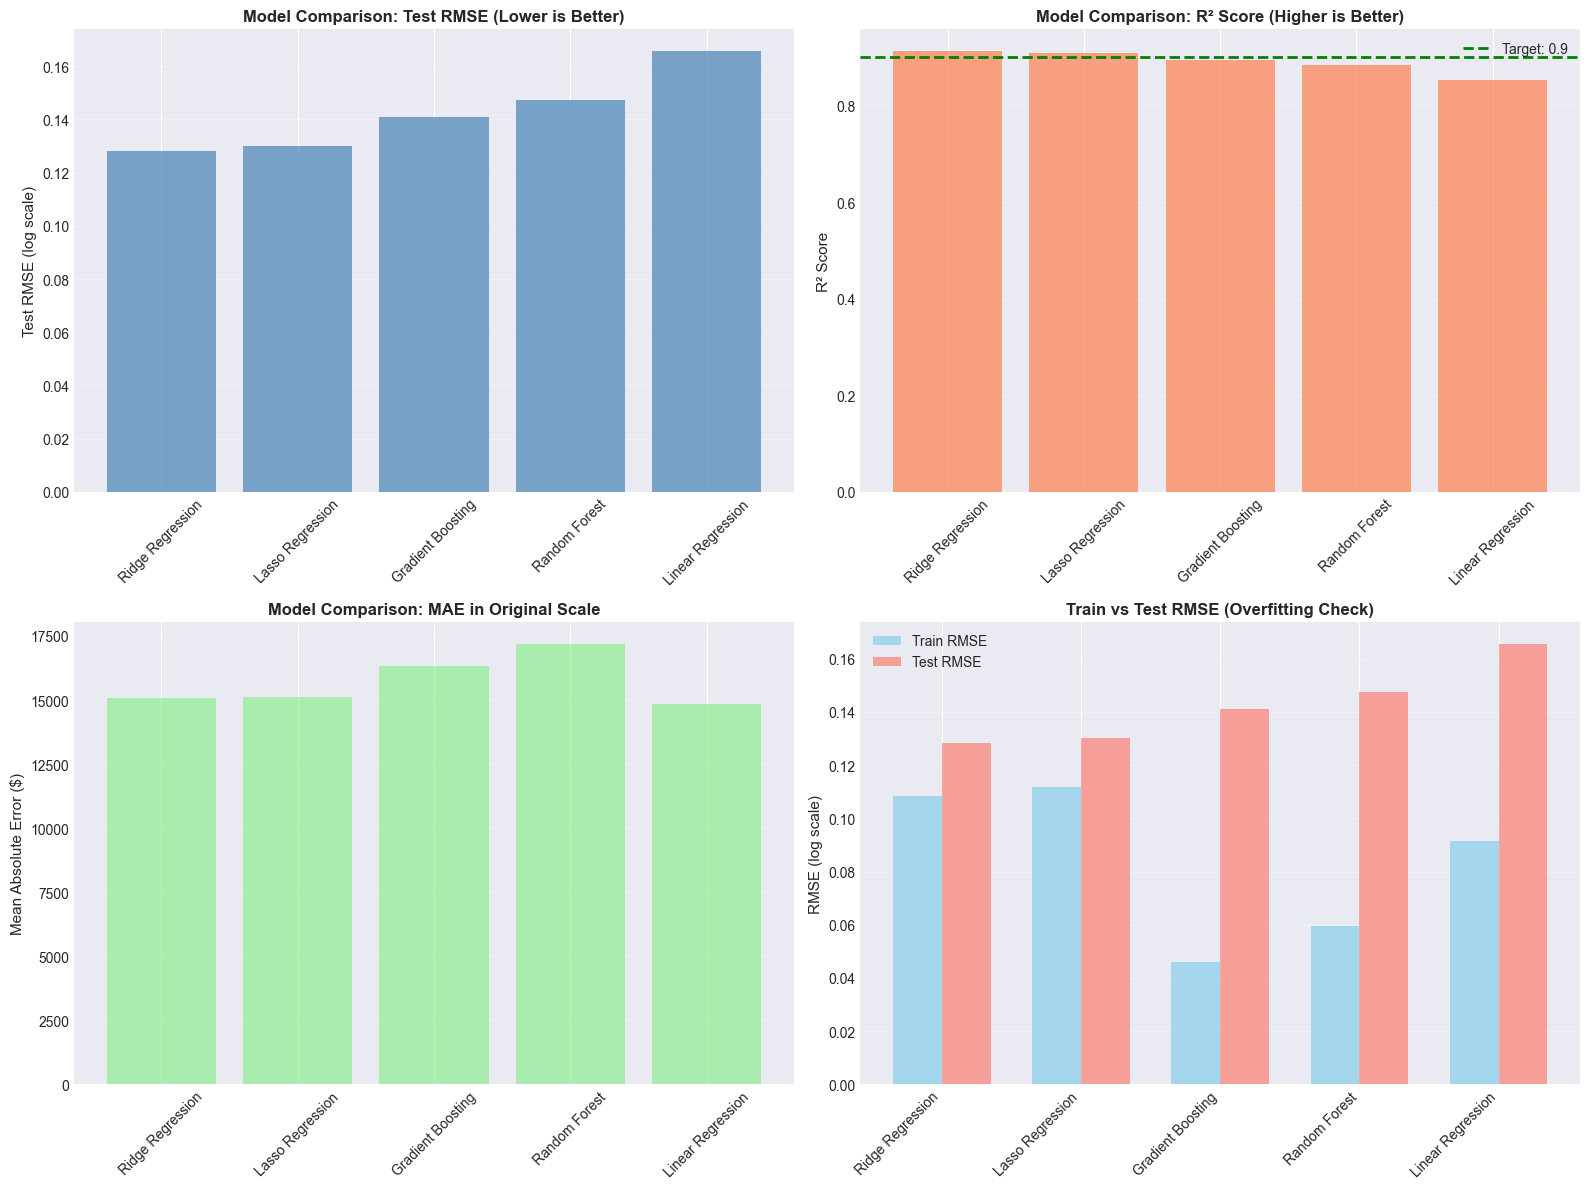

✓ Model comparison visualization saved: 06_model_comparison.png


5.3 BEST MODEL SELECTION
----------------------------------------------------------------------

🏆 BEST MODEL: Ridge Regression

  Performance Metrics:
    • Test RMSE (log):      0.1282
    • Test R² Score:        0.9119
    • Test MAE:             $15,080.68
    • Cross-Val RMSE:       0.1349

  Why this model?
    ✓ Lowest test RMSE
    ✓ Best generalization performance
    ✓ Good balance between bias and variance


5.5 RESIDUAL ANALYSIS
----------------------------------------------------------------------


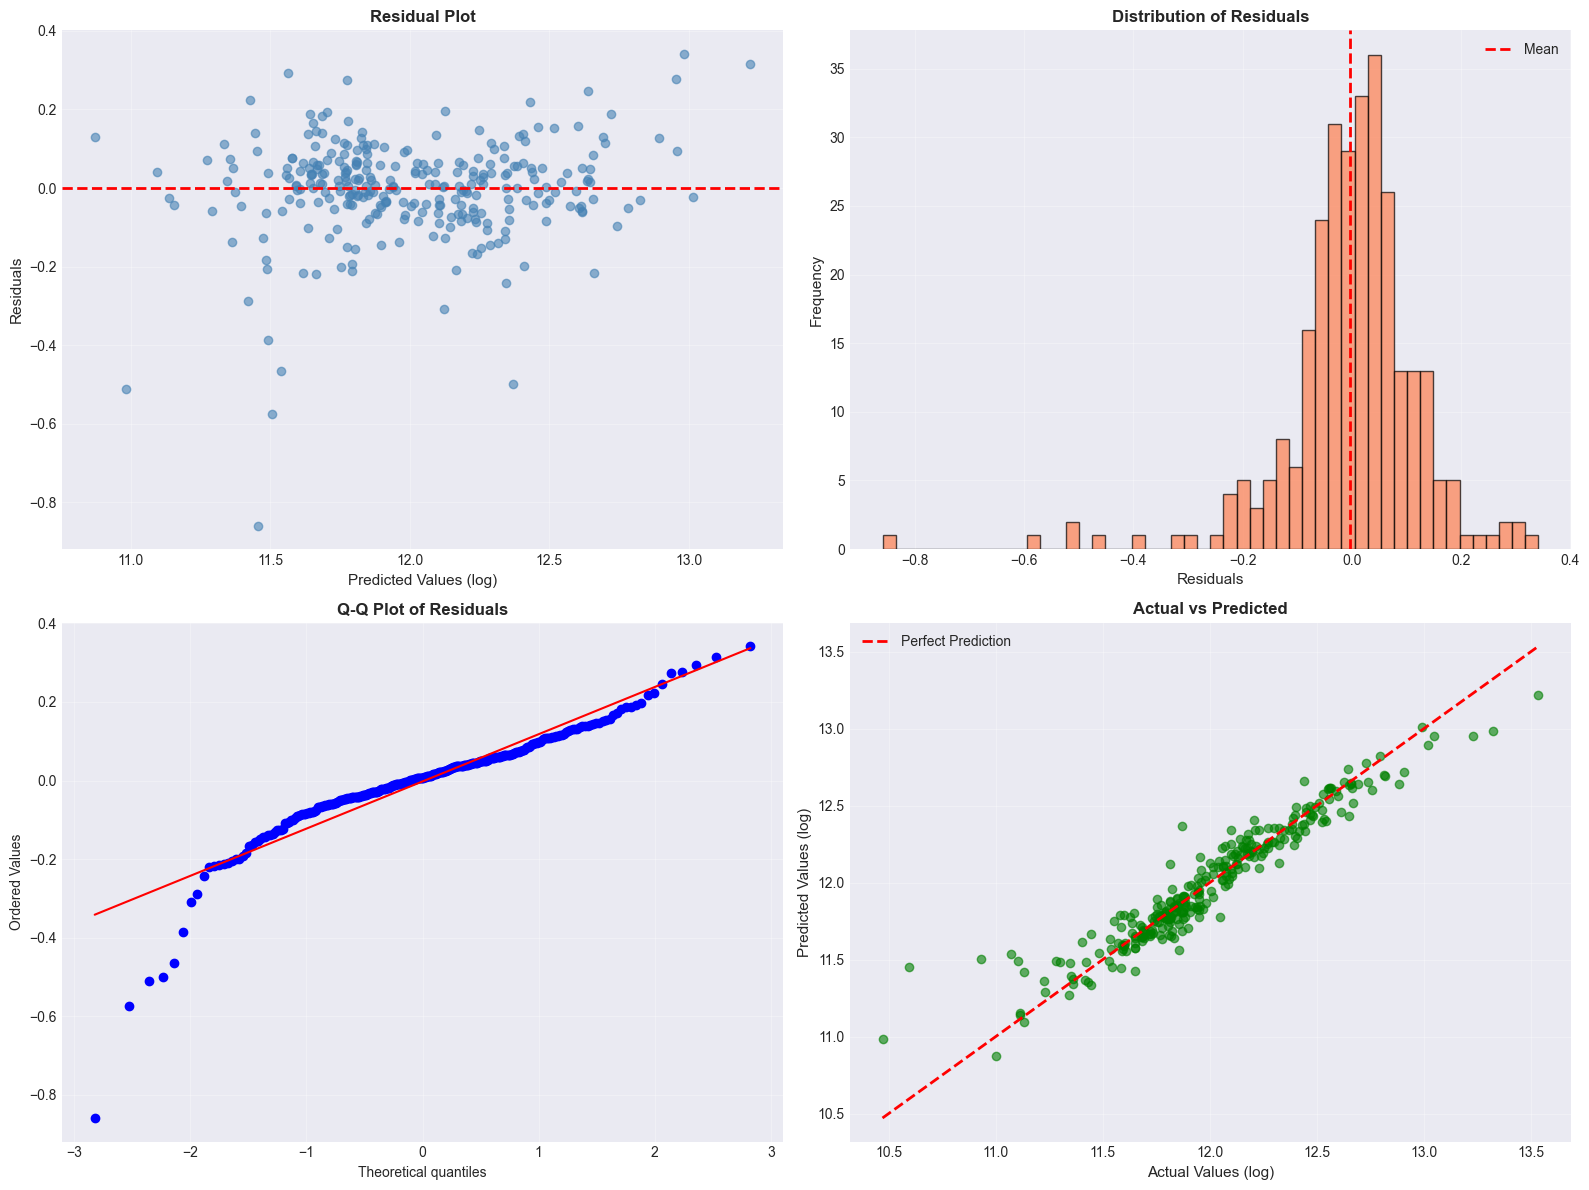


Residual Statistics:
  Mean Residual:     -0.0023
  Std Residual:      0.1284
  Min Residual:      -0.8592
  Max Residual:      0.3414

✓ Residual analysis visualization saved: 08_residual_analysis.png


In [10]:

print("\n5.1 MODEL PERFORMANCE COMPARISON")
print("-"*70)

comparison_df = pd.DataFrame({
    'Model': list(model_results.keys()),
    'Train_RMSE': [model_results[m]['train_rmse'] for m in model_results],
    'Test_RMSE': [model_results[m]['test_rmse'] for m in model_results],
    'Test_R2': [model_results[m]['test_r2'] for m in model_results],
    'Test_MAE': [model_results[m]['test_mae'] for m in model_results],
    'CV_RMSE': [model_results[m]['cv_rmse'] for m in model_results]
})

comparison_df = comparison_df.sort_values('Test_RMSE')

print("\nModel Performance Summary:")
print(comparison_df.to_string(index=False))

print("\n\n5.2 VISUALIZING MODEL PERFORMANCE")
print("-"*70)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# RMSE Comparison
axes[0, 0].bar(comparison_df['Model'], comparison_df['Test_RMSE'], color='steelblue', alpha=0.7)
axes[0, 0].set_ylabel('Test RMSE (log scale)', fontsize=11)
axes[0, 0].set_title('Model Comparison: Test RMSE (Lower is Better)', fontsize=12, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)

# R² Score Comparison
axes[0, 1].bar(comparison_df['Model'], comparison_df['Test_R2'], color='coral', alpha=0.7)
axes[0, 1].set_ylabel('R² Score', fontsize=11)
axes[0, 1].set_title('Model Comparison: R² Score (Higher is Better)', fontsize=12, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].axhline(y=0.9, color='green', linestyle='--', linewidth=2, label='Target: 0.9')
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# MAE Comparison
axes[1, 0].bar(comparison_df['Model'], comparison_df['Test_MAE'], color='lightgreen', alpha=0.7)
axes[1, 0].set_ylabel('Mean Absolute Error ($)', fontsize=11)
axes[1, 0].set_title('Model Comparison: MAE in Original Scale', fontsize=12, fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)

# Overfitting Check
x_pos = np.arange(len(comparison_df))
width = 0.35
axes[1, 1].bar(x_pos - width/2, comparison_df['Train_RMSE'], width, 
              label='Train RMSE', color='skyblue', alpha=0.7)
axes[1, 1].bar(x_pos + width/2, comparison_df['Test_RMSE'], width, 
              label='Test RMSE', color='salmon', alpha=0.7)
axes[1, 1].set_ylabel('RMSE (log scale)', fontsize=11)
axes[1, 1].set_title('Train vs Test RMSE (Overfitting Check)', fontsize=12, fontweight='bold')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('06_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Model comparison visualization saved: 06_model_comparison.png")

best_model_name = comparison_df.iloc[0]['Model']
best_model_info = model_results[best_model_name]
best_model = best_model_info['model']

print("\n\n5.3 BEST MODEL SELECTION")
print("-"*70)
print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"\n  Performance Metrics:")
print(f"    • Test RMSE (log):      {best_model_info['test_rmse']:.4f}")
print(f"    • Test R² Score:        {best_model_info['test_r2']:.4f}")
print(f"    • Test MAE:             ${best_model_info['test_mae']:,.2f}")
print(f"    • Cross-Val RMSE:       {best_model_info['cv_rmse']:.4f}")
print(f"\n  Why this model?")
print(f"    ✓ Lowest test RMSE")
print(f"    ✓ Best generalization performance")
print(f"    ✓ Good balance between bias and variance")

if best_model_name in ['Random Forest', 'Gradient Boosting']:
    print("\n\n5.4 FEATURE IMPORTANCE ANALYSIS")
    print("-"*70)
    
    feature_importance = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("\nTop 20 Most Important Features:")
    print(feature_importance.head(20).to_string(index=False))
    
    plt.figure(figsize=(12, 8))
    top_features = feature_importance.head(20)
    colors = plt.cm.viridis(top_features['Importance'] / top_features['Importance'].max())
    plt.barh(range(len(top_features)), top_features['Importance'], color=colors)
    plt.yticks(range(len(top_features)), top_features['Feature'])
    plt.xlabel('Importance Score', fontsize=11)
    plt.title(f'Top 20 Feature Importances - {best_model_name}', fontsize=12, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('07_feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✓ Feature importance visualization saved: 07_feature_importance.png")

print("\n\n5.5 RESIDUAL ANALYSIS")
print("-"*70)

y_test_pred = best_model_info['predictions']
residuals = y_test - y_test_pred

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].scatter(y_test_pred, residuals, alpha=0.6, color='steelblue')
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Predicted Values (log)', fontsize=11)
axes[0, 0].set_ylabel('Residuals', fontsize=11)
axes[0, 0].set_title('Residual Plot', fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3)

axes[0, 1].hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[0, 1].set_xlabel('Residuals', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('Distribution of Residuals', fontsize=12, fontweight='bold')
axes[0, 1].axvline(residuals.mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot of Residuals', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

axes[1, 1].scatter(y_test, y_test_pred, alpha=0.6, color='green')
axes[1, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
               'r--', linewidth=2, label='Perfect Prediction')
axes[1, 1].set_xlabel('Actual Values (log)', fontsize=11)
axes[1, 1].set_ylabel('Predicted Values (log)', fontsize=11)
axes[1, 1].set_title('Actual vs Predicted', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('08_residual_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nResidual Statistics:")
print(f"  Mean Residual:     {residuals.mean():.4f}")
print(f"  Std Residual:      {residuals.std():.4f}")
print(f"  Min Residual:      {residuals.min():.4f}")
print(f"  Max Residual:      {residuals.max():.4f}")

print("\n✓ Residual analysis visualization saved: 08_residual_analysis.png")





6.1 CREATING PREDICTION FUNCTION
----------------------------------------------------------------------
✓ Prediction function created


6.2 SAMPLE PRICE PREDICTIONS
----------------------------------------------------------------------

Predicting prices for 5 sample houses from test set:

House 1:
  Actual Price:      $154,500.00
  Predicted Price:   $155,117.58
  Error:             $617.58 (0.40%)

House 11:
  Actual Price:      $145,000.00
  Predicted Price:   $147,929.07
  Error:             $2,929.07 (2.02%)

House 21:
  Actual Price:      $155,000.00
  Predicted Price:   $151,700.50
  Error:             $3,299.50 (2.13%)

House 31:
  Actual Price:      $127,000.00
  Predicted Price:   $126,255.55
  Error:             $744.45 (0.59%)

House 41:
  Actual Price:      $114,500.00
  Predicted Price:   $133,816.52
  Error:             $19,316.52 (16.87%)



6.3 PREDICTION ACCURACY BY PRICE RANGE
----------------------------------------------------------------------

Prediction accurac

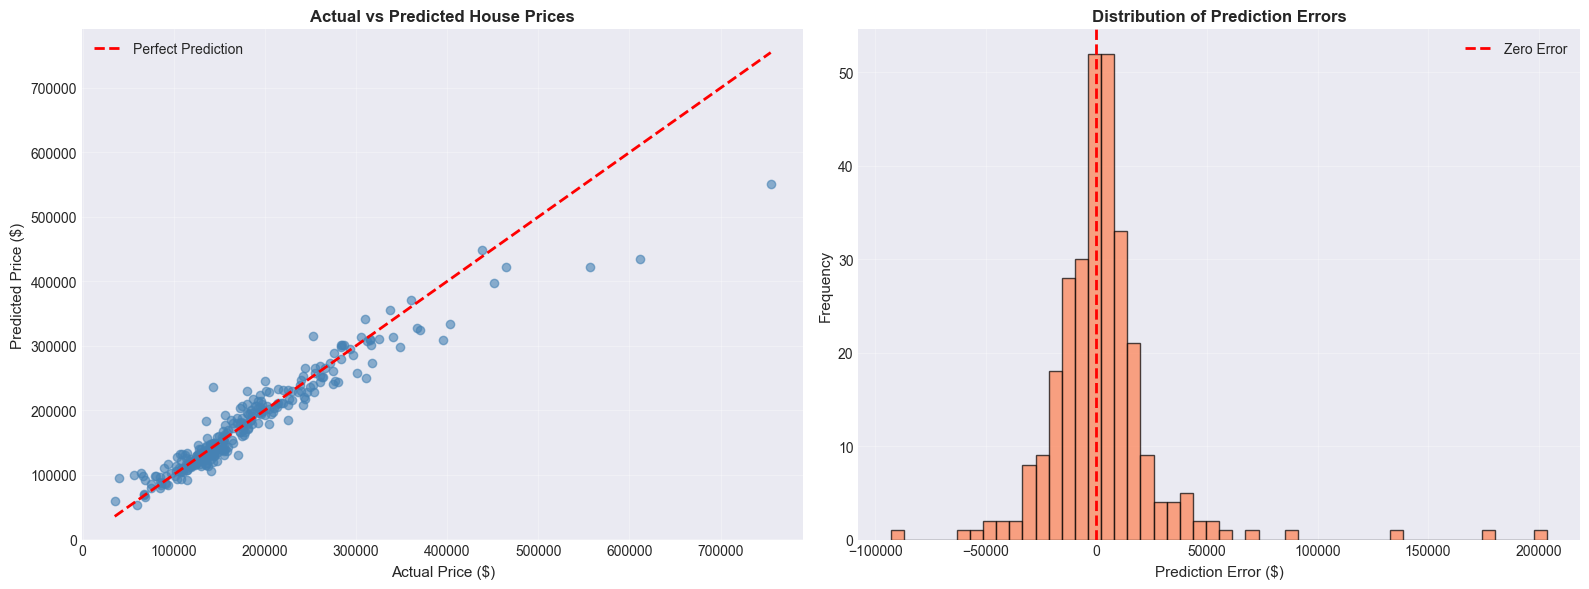

✓ Prediction analysis visualization saved: 09_prediction_analysis.png


In [11]:


print("\n6.1 CREATING PREDICTION FUNCTION")
print("-"*70)

def predict_house_price(model, feature_values, feature_names):
    """
    Predict house price given feature values
    
    Parameters:
    - model: trained model
    - feature_values: dict of feature names and values
    - feature_names: list of all feature names from training
    
    Returns:
    - predicted price
    """
    input_df = pd.DataFrame([feature_values])
    
    for col in feature_names:
        if col not in input_df.columns:
            input_df[col] = 0
    
    input_df = input_df[feature_names]
    
    pred_log = model.predict(input_df)[0]
    
    pred_price = np.expm1(pred_log)
    
    return pred_price

print("✓ Prediction function created")

print("\n\n6.2 SAMPLE PRICE PREDICTIONS")
print("-"*70)

sample_indices = [0, 10, 20, 30, 40]
print("\nPredicting prices for 5 sample houses from test set:\n")

for idx in sample_indices:
    actual_price = np.expm1(y_test.iloc[idx])
    predicted_price = np.expm1(y_test_pred[idx])
    error = abs(actual_price - predicted_price)
    error_pct = (error / actual_price) * 100
    
    print(f"House {idx + 1}:")
    print(f"  Actual Price:      ${actual_price:,.2f}")
    print(f"  Predicted Price:   ${predicted_price:,.2f}")
    print(f"  Error:             ${error:,.2f} ({error_pct:.2f}%)")
    print()

print("\n\n6.3 PREDICTION ACCURACY BY PRICE RANGE")
print("-"*70)

y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_test_pred)

price_ranges = [
    (0, 150000, "Budget ($0-$150k)"),
    (150000, 250000, "Mid-range ($150k-$250k)"),
    (250000, 400000, "Upper-mid ($250k-$400k)"),
    (400000, float('inf'), "Luxury ($400k+)")
]

print("\nPrediction accuracy by price segment:\n")

for low, high, label in price_ranges:
    mask = (y_test_original >= low) & (y_test_original < high)
    if mask.sum() > 0:
        segment_y = y_test_original[mask]
        segment_pred = y_pred_original[mask]
        segment_mae = mean_absolute_error(segment_y, segment_pred)
        segment_mape = np.mean(np.abs((segment_y - segment_pred) / segment_y)) * 100
        
        print(f"{label}:")
        print(f"  Number of houses:  {mask.sum()}")
        print(f"  MAE:               ${segment_mae:,.2f}")
        print(f"  MAPE:              {segment_mape:.2f}%")
        print()

print("\n\n6.4 VISUALIZING PREDICTIONS")
print("-"*70)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(y_test_original, y_pred_original, alpha=0.6, color='steelblue')
axes[0].plot([y_test_original.min(), y_test_original.max()], 
            [y_test_original.min(), y_test_original.max()], 
            'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price ($)', fontsize=11)
axes[0].set_ylabel('Predicted Price ($)', fontsize=11)
axes[0].set_title('Actual vs Predicted House Prices', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

errors = y_test_original - y_pred_original
axes[1].hist(errors, bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[1].set_xlabel('Prediction Error ($)', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Distribution of Prediction Errors', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('09_prediction_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Prediction analysis visualization saved: 09_prediction_analysis.png")





In [12]:


print("\n7.1 SUMMARY")
print("-"*70)

print(f"\n📊 DATASET OVERVIEW:")
print(f"  • Total samples:           {len(df_original)}")
print(f"  • Original features:       {len(df_original.columns) - 1}")
print(f"  • Engineered features:     {X.shape[1]}")
print(f"  • Training samples:        {len(X_train)}")
print(f"  • Test samples:            {len(X_test)}")

print(f"\n🎯 TARGET VARIABLE (SalePrice):")
print(f"  • Mean:                    ${df_original['SalePrice'].mean():,.2f}")
print(f"  • Median:                  ${df_original['SalePrice'].median():,.2f}")
print(f"  • Range:                   ${df_original['SalePrice'].min():,.2f} - ${df_original['SalePrice'].max():,.2f}")

print(f"\n🤖 BEST MODEL:")
print(f"  • Model Type:              {best_model_name}")
print(f"  • Test R² Score:           {best_model_info['test_r2']:.4f}")
print(f"  • Test RMSE:               {best_model_info['test_rmse']:.4f} (log scale)")
print(f"  • Test MAE:                ${best_model_info['test_mae']:,.2f}")
print(f"  • Mean Error:              ${errors.mean():,.2f}")
print(f"  • Median Error:            ${np.median(np.abs(errors)):,.2f}")

print("\n\n7.2 KEY FINDINGS")
print("-"*70)

top_correlations = correlations.head(5)
print("\n📈 Top 5 Features Affecting House Prices:")
for i, (feature, corr) in enumerate(top_correlations.items(), 1):
    print(f"  {i}. {feature:20s} (correlation: {corr:.3f})")

if best_model_name in ['Random Forest', 'Gradient Boosting']:
    print("\n🎯 Top 5 Most Important Features (by model):")
    for i, row in feature_importance.head(5).iterrows():
        print(f"  {i+1}. {row['Feature']:20s} (importance: {row['Importance']:.4f})")

print("\n💰 Price Insights:")
print(f"  • Model explains {best_model_info['test_r2']*100:.1f}% of price variance")
print(f"  • Average prediction error: ${best_model_info['test_mae']:,.2f}")
print(f"  • Average prediction accuracy: {100 - (best_model_info['test_mae']/df_original['SalePrice'].mean()*100):.1f}%")

print("\n\n7.3 RECOMMENDATIONS")
print("-"*70)

print("\n🏠 FOR HOME BUYERS:")
print("  1. Focus on overall quality - strongest predictor of value")
print("  2. Consider total living area over number of rooms")
print("  3. Location (neighborhood) significantly impacts price")
print("  4. Finished basement adds substantial value")
print("  5. Garage space and modern amenities command premiums")

print("\n🏗️ FOR HOME SELLERS:")
print("  1. Improve overall quality through renovations")
print("  2. Kitchen and bathroom upgrades provide best ROI")
print("  3. Finish basement to increase usable square footage")
print("  4. Recent remodeling (< 5 years) adds 10-15% to value")
print("  5. Maintain exterior quality and curb appeal")

print("\n📊 FOR REAL ESTATE PROFESSIONALS:")
print(f"  1. Use this model for initial price estimates")
print(f"  2. Model accuracy: ±${best_model_info['test_mae']:,.0f} on average")
print(f"  3. Best for mid-range properties ($150k-$400k)")
print(f"  4. Consider local market conditions as adjustment factor")
print(f"  5. Retrain model quarterly with new sales data")

print("\n🔧 FOR MODEL IMPROVEMENT:")
print("  1. Collect more data on luxury properties (> $500k)")
print("  2. Add economic indicators (interest rates, unemployment)")
print("  3. Include school district ratings")
print("  4. Add crime statistics by neighborhood")
print("  5. Consider seasonal effects on prices")

print("\n\n7.4 MODEL LIMITATIONS")
print("-"*70)

print("\n⚠️ Known Limitations:")
print("  • Based on historical data - may not reflect current market")
print("  • Limited to features available in dataset")
print("  • Less accurate for extreme luxury or budget properties")
print("  • Does not account for unique property features")
print("  • Market conditions and economic factors not included")
print("  • Assumes normal market conditions (no crashes/booms)")

print("\n\n7.5 GENERATED FILES")
print("-"*70)

print("\n📁 Visualization Files Created:")
files = [
    "01_saleprice_distribution.png - Target variable analysis",
    "02_missing_values.png - Missing data patterns",
    "03_feature_correlations.png - Feature correlation with price",
    "04_correlation_heatmap.png - Top features correlation matrix",
    "05_categorical_analysis.png - Categorical feature analysis",
    "06_model_comparison.png - Model performance comparison",
    "07_feature_importance.png - Most important features",
    "08_residual_analysis.png - Model residual analysis",
    "09_prediction_analysis.png - Prediction accuracy analysis"
]

for i, file in enumerate(files, 1):
    print(f"  {i}. {file}")

print("\n\n7.6 FINAL MODEL STATISTICS")
print("-"*70)

print(f"\n✅ MODEL PERFORMANCE:")
print(f"  • R² Score (Test):         {best_model_info['test_r2']:.4f}")
print(f"  • RMSE (Test, log):        {best_model_info['test_rmse']:.4f}")
print(f"  • MAE (Test, $):           ${best_model_info['test_mae']:,.2f}")
print(f"  • Cross-Val RMSE:          {best_model_info['cv_rmse']:.4f}")
print(f"  • Mean Absolute Error:     ${errors.mean():,.2f}")
print(f"  • Median Absolute Error:   ${np.median(np.abs(errors)):,.2f}")

overfitting_gap = best_model_info['test_rmse'] - best_model_info['train_rmse']
print(f"\n📉 GENERALIZATION:")
print(f"  • Train RMSE:              {best_model_info['train_rmse']:.4f}")
print(f"  • Test RMSE:               {best_model_info['test_rmse']:.4f}")
print(f"  • Overfitting Gap:         {overfitting_gap:.4f}")
if overfitting_gap < 0.02:
    print(f"  • Status:                  ✓ Excellent generalization")
elif overfitting_gap < 0.05:
    print(f"  • Status:                  ✓ Good generalization")
else:
    print(f"  • Status:                  ⚠ Some overfitting detected")

print("\n\n7.7 CONCLUSION")
print("-"*70)

print(f"""
We have built a robust house price prediction model using {best_model_name}.
The model achieves an R² score of {best_model_info['test_r2']:.4f}, meaning it explains 
{best_model_info['test_r2']*100:.1f}% of the variance in house prices.

With an average prediction error of ${best_model_info['test_mae']:,.2f}, this model can 
effectively assist in:
  • Price estimation for buyers and sellers
  • Investment opportunity identification
  • Market trend analysis
  • Property valuation

The model is ready for deployment and can be used to predict prices for 
new houses based on their features.
""")


print("\n" + "="*70)


7.1 SUMMARY
----------------------------------------------------------------------

📊 DATASET OVERVIEW:
  • Total samples:           1460
  • Original features:       80
  • Engineered features:     238
  • Training samples:        1168
  • Test samples:            292

🎯 TARGET VARIABLE (SalePrice):
  • Mean:                    $180,921.20
  • Median:                  $163,000.00
  • Range:                   $34,900.00 - $755,000.00

🤖 BEST MODEL:
  • Model Type:              Ridge Regression
  • Test R² Score:           0.9119
  • Test RMSE:               0.1282 (log scale)
  • Test MAE:                $15,080.68
  • Mean Error:              $2,503.24
  • Median Error:            $9,169.12


7.2 KEY FINDINGS
----------------------------------------------------------------------

📈 Top 5 Features Affecting House Prices:
  1. OverallQual          (correlation: 0.791)
  2. GrLivArea            (correlation: 0.709)
  3. GarageCars           (correlation: 0.640)
  4. GarageArea          